In [1]:
# Imports e configurações necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import hashlib
import shutil
import re
from datetime import datetime as dt
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Carregar os CSVs
df_incidents = pd.read_csv('data/raw/incidents_master.csv')
df_financial = pd.read_csv('data/raw/financial_impact.csv')
df_market    = pd.read_csv('data/raw/market_impact.csv')

In [3]:
# primeiras linhas
df_incidents.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,https://www.sterling-forge-markets-ho.com/news...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,https://www.sierra-quantum-innovation.com/news...,NaN,company_pr,2,79.82,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [4]:
# shape dos três datasets
print('incidents_master :', df_incidents.shape)
print('financial_impact :', df_financial.shape)
print('market_impact    :', df_market.shape)

incidents_master : (850, 32)
financial_impact : (778, 19)
market_impact    : (358, 31)


In [5]:
# tipos e nulos
df_incidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    object 
 1   company_name              850 non-null    object 
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    object 
 4   industry_primary          850 non-null    object 
 5   industry_secondary        153 non-null    object 
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    object 
 9   incident_date             850 non-null    object 
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    object 
 12  disclosure_date           850 non-null    object 
 13  attack_vector_primary     850 non-null    object 
 14  attack_vec

In [6]:
# estatísticas descritivas
df_financial.describe()

,direct_loss_usd,ransom_demanded_usd,ransom_paid_usd,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd
count,7.780000e+02,2.060000e+02,8.600000e+01,7.780000e+02,7.780000e+02,1.320000e+02,4.350000e+02,7.780000e+02,7.780000e+02,7.780000e+02,7.780000e+02
mean,3.652294e+07,8.017672e+06,4.497464e+06,2.618556e+07,7.309469e+06,2.834303e+06,2.665044e+07,7.099600e+07,5.111886e+07,1.059982e+08,7.501910e+07
std,1.196191e+08,1.580389e+07,9.186802e+06,7.816093e+07,2.390878e+07,7.363815e+06,7.593903e+07,2.151881e+08,1.471999e+08,3.283143e+08,2.233519e+08
min,9.000000e+04,5.000000e+04,1.610098e+04,5.703142e+04,1.276379e+04,5.000000e+04,6.280104e+04,1.737931e+05,1.256943e+05,2.752890e+05,1.737931e+05
25%,2.834239e+06,6.578965e+05,4.247265e+05,2.055169e+06,4.748212e+05,2.771979e+05,2.277000e+06,6.166441e+06,4.519930e+06,8.766029e+06,6.489252e+06
50%,8.525071e+06,1.979266e+06,1.129759e+06,6.129803e+06,1.506969e+06,9.141517e+05,6.316200e+06,1.656491e+07,1.185589e+07,2.534531e+07,1.790865e+07
75%,2.609037e+07,6.303181e+06,3.589926e+06,1.840980e+07,4.756604e+06,2.106179e+06,1.844803e+07,5.259585e+07,3.786537e+07,7.729790e+07,5.589355e+07
max,2.302300e+09,7.500000e+07,5.188418e+07,1.238193e+09,3.828183e+08,5.114644e+07,1.054416e+09,3.451548e+09,2.108922e+09,5.872051e+09,3.451548e+09


In [7]:
# Padroniza nomes de colunas para snake_case
def normalize_columns(df):
    cols = []
    for c in df.columns:
        c = c.strip().lower()
        c = re.sub(r'[\s\-\.]+', '_', c)
        c = re.sub(r'[^a-z0-9_]', '', c)
        c = re.sub(r'_+', '_', c).strip('_')
        cols.append(c)
    df.columns = cols
    return df

df_incidents = normalize_columns(df_incidents)
df_financial = normalize_columns(df_financial)
df_market    = normalize_columns(df_market)

print('Colunas incidents_master:')
print(df_incidents.columns.tolist())

Colunas incidents_master:
['incident_id', 'company_name', 'company_revenue_usd', 'country_hq', 'industry_primary', 'industry_secondary', 'employee_count', 'is_public_company', 'stock_ticker', 'incident_date', 'incident_date_estimated', 'discovery_date', 'disclosure_date', 'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 'attributed_group', 'attribution_confidence', 'data_compromised_records', 'data_type', 'systems_affected', 'downtime_hours', 'data_source_primary', 'data_source_secondary', 'data_source_type', 'confidence_tier', 'quality_score', 'quality_grade', 'review_flag', 'notes', 'created_at', 'updated_at']


In [8]:
# Função para calcular hash SHA-256 de um arquivo
def file_hash(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

# Caminhos dos arquivos originais
path_incidents = 'data/raw/incidents_master.csv'
path_financial = 'data/raw/financial_impact.csv'
path_market    = 'data/raw/market_impact.csv'

print('Hash incidents_master:', file_hash(path_incidents)[:20], '...')
print('Hash financial_impact:', file_hash(path_financial)[:20], '...')
print('Hash market_impact   :', file_hash(path_market)[:20], '...')

Hash incidents_master: 9819d9ad6baeadca4c50 ...
Hash financial_impact: 9e375eb6f35b70d40166 ...
Hash market_impact   : d7f4ef0645bbc50f9e4c ...


In [9]:
ts = dt.now().isoformat()

df_bronze_incidents = df_incidents.copy()
df_bronze_incidents['_ingestion_timestamp'] = ts
df_bronze_incidents['_source_file']         = 'incidents_master.csv'
df_bronze_incidents['_file_hash_sha256']    = file_hash(path_incidents)
df_bronze_incidents['_file_size_bytes']     = Path(path_incidents).stat().st_size

df_bronze_financial = df_financial.copy()
df_bronze_financial['_ingestion_timestamp'] = ts
df_bronze_financial['_source_file']         = 'financial_impact.csv'
df_bronze_financial['_file_hash_sha256']    = file_hash(path_financial)
df_bronze_financial['_file_size_bytes']     = Path(path_financial).stat().st_size

df_bronze_market = df_market.copy()
df_bronze_market['_ingestion_timestamp'] = ts
df_bronze_market['_source_file']         = 'market_impact.csv'
df_bronze_market['_file_hash_sha256']    = file_hash(path_market)
df_bronze_market['_file_size_bytes']     = Path(path_market).stat().st_size

df_bronze_incidents.tail(2)

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,quality_score,quality_grade,review_flag,notes,created_at,updated_at,_ingestion_timestamp,_source_file,_file_hash_sha256,_file_size_bytes
848,2023-0620-002,Lambert Studios Inc.,5.327039e+09,NO,71,NaN,30630,True,LAMB.OL,2023-06-20,...,99.22,Gold,NaN,Partial remediation completed within 48h; full...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-15T15:04:48.753288,incidents_master.csv,9819d9ad6baeadca4c503d1146def6504da32e42b9e14e...,438941
849,2021-0419-001,Irving MedTech PLC,4.859082e+08,GB,62,31-33,2537,False,NaN,2021-04-19,...,77.32,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-15T15:04:48.753288,incidents_master.csv,9819d9ad6baeadca4c503d1146def6504da32e42b9e14e...,438941


In [10]:
# Crie as pastas e salve os arquivos Bronze
Path('data/bronze/incidents_master').mkdir(parents=True, exist_ok=True)
Path('data/bronze/financial_impact').mkdir(parents=True, exist_ok=True)
Path('data/bronze/market_impact').mkdir(parents=True, exist_ok=True)

df_bronze_incidents.to_parquet('data/bronze/incidents_master/incidents_master.parquet', index=False)
df_bronze_financial.to_parquet('data/bronze/financial_impact/financial_impact.parquet', index=False)
df_bronze_market.to_parquet('data/bronze/market_impact/market_impact.parquet', index=False)

print('Tamanho incidents_master.parquet :', Path('data/bronze/incidents_master/incidents_master.parquet').stat().st_size, 'bytes')
print('Tamanho financial_impact.parquet :', Path('data/bronze/financial_impact/financial_impact.parquet').stat().st_size, 'bytes')
print('Tamanho market_impact.parquet    :', Path('data/bronze/market_impact/market_impact.parquet').stat().st_size, 'bytes')

Tamanho incidents_master.parquet : 126997 bytes
Tamanho financial_impact.parquet : 76485 bytes
Tamanho market_impact.parquet    : 93557 bytes


<details><summary>Dica</summary>

Salve em `data/bronze/_meta/`. O JSON deve conter: nome do arquivo, hash, tamanho, número de linhas, colunas, timestamp.

Use `json.dump(..., indent=2)` para deixar legível.

</details>

In [11]:
# pasta de metadados dos JSONs
Path('data/bronze/_meta').mkdir(parents=True, exist_ok=True)

def build_meta(source_path, df_bronze, parquet_path):
    return {
        'source_file'      : Path(source_path).name,
        'parquet_path'     : str(parquet_path),
        'file_hash_sha256' : file_hash(source_path),
        'file_size_bytes'  : Path(source_path).stat().st_size,
        'num_rows'         : len(df_bronze),
        'num_columns'      : len(df_bronze.columns),
        'columns'          : df_bronze.columns.tolist(),
        'ingestion_ts'     : ts,
        'layer'            : 'bronze'
    }

meta_incidents = build_meta(path_incidents, df_bronze_incidents,
                            'data/bronze/incidents_master/incidents_master.parquet')
meta_financial = build_meta(path_financial, df_bronze_financial,
                            'data/bronze/financial_impact/financial_impact.parquet')
meta_market    = build_meta(path_market, df_bronze_market,
                            'data/bronze/market_impact/market_impact.parquet')

for name, meta in [('incidents_master', meta_incidents),
                   ('financial_impact', meta_financial),
                   ('market_impact',    meta_market)]:
    with open(f'data/bronze/_meta/{name}_meta.json', 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

summary = [meta_incidents, meta_financial, meta_market]
with open('data/bronze/_meta/bronze_ingestion_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('Metadados salvos em data/bronze/_meta/')

Metadados salvos em data/bronze/_meta/


In [12]:
# Resumo da ingestão
resumo = pd.DataFrame([{
    'Dataset'        : m['source_file'],
    'Linhas'         : m['num_rows'],
    'Colunas'        : m['num_columns'],
    'Tamanho (bytes)': m['file_size_bytes'],
    'Hash (16ch)'    : m['file_hash_sha256'][:16] + '...'
} for m in summary])

display(resumo)

,Dataset,Linhas,Colunas,Tamanho (bytes),Hash (16ch)
0,incidents_master.csv,850,36,438941,9819d9ad6baeadca...
1,financial_impact.csv,778,23,170578,9e375eb6f35b70d4...
2,market_impact.csv,358,35,109318,d7f4ef0645bbc50f...


In [13]:
# Contagem e percentual de nulos por coluna —> incidents_master
nulos = df_bronze_incidents.isnull().sum()
pct   = (df_bronze_incidents.isnull().mean() * 100).round(1)

display(pd.DataFrame({'Nulos': nulos, '% Nulo': pct}).query('Nulos > 0').sort_values('% Nulo', ascending=False))

,Nulos,% Nulo
review_flag,780,91.8
industry_secondary,697,82.0
attack_vector_secondary,639,75.2
notes,636,74.8
data_source_secondary,464,54.6
stock_ticker,438,51.5
downtime_hours,430,50.6
attribution_confidence,368,43.3
attributed_group,368,43.3
attack_chain,275,32.4


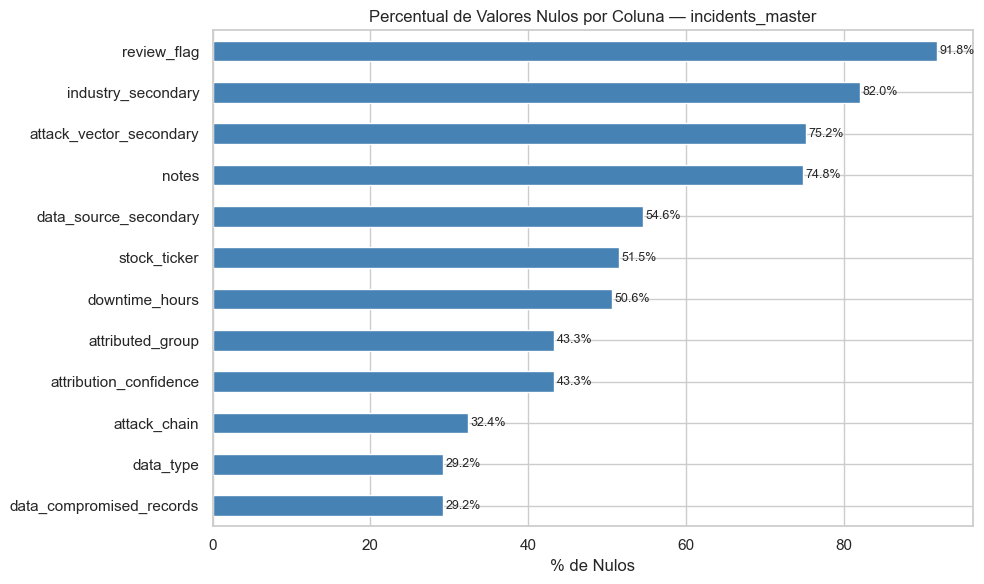

In [14]:
# Visualização do mapa de nulos
nulos_plot = pct[pct > 0].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
nulos_plot.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de Nulos')
ax.set_title('Percentual de Valores Nulos por Coluna — incidents_master')
for i, v in enumerate(nulos_plot):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# Verificação de duplicatas
print('=== incidents_master ===')
print('Linhas duplicadas (linha inteira)  :', df_bronze_incidents.duplicated().sum())
print('Linhas duplicadas (por incident_id):', df_bronze_incidents.duplicated(subset=['incident_id']).sum())

print('\n=== financial_impact ===')
print('Linhas duplicadas (linha inteira)  :', df_bronze_financial.duplicated().sum())
print('Linhas duplicadas (por incident_id):', df_bronze_financial.duplicated(subset=['incident_id']).sum())

print('\n=== market_impact ===')
print('Linhas duplicadas (linha inteira)  :', df_bronze_market.duplicated().sum())
print('Linhas duplicadas (por incident_id):', df_bronze_market.duplicated(subset=['incident_id']).sum())

=== incidents_master ===
Linhas duplicadas (linha inteira)  : 0
Linhas duplicadas (por incident_id): 0

=== financial_impact ===
Linhas duplicadas (linha inteira)  : 0
Linhas duplicadas (por incident_id): 0

=== market_impact ===
Linhas duplicadas (linha inteira)  : 0
Linhas duplicadas (por incident_id): 0


In [16]:
# Análise de tipos de dado —> incidents_master
tipos = pd.DataFrame({
    'Dtype'  : df_bronze_incidents.dtypes,
    'Nulos'  : df_bronze_incidents.isna().sum(),
    'Únicos' : df_bronze_incidents.nunique()
})
display(tipos)

,Dtype,Nulos,Únicos
incident_id,object,0,850
company_name,object,0,750
company_revenue_usd,float64,0,750
country_hq,object,0,38
industry_primary,object,0,20
industry_secondary,object,697,19
employee_count,int64,0,732
is_public_company,bool,0,2
stock_ticker,object,438,359
incident_date,object,0,691


In [17]:
# Verificação de colunas de data
date_cols = ['incident_date', 'discovery_date', 'disclosure_date', 'created_at', 'updated_at']
for col in date_cols:
    if col in df_bronze_incidents.columns:
        print(f'{col} → dtype: {df_bronze_incidents[col].dtype} | exemplo: {df_bronze_incidents[col].dropna().iloc[0]}')

incident_date → dtype: object | exemplo: 2021-05-08
discovery_date → dtype: object | exemplo: 2021-05-12
disclosure_date → dtype: object | exemplo: 2021-06-20
created_at → dtype: object | exemplo: 2026-02-12T10:00:00Z
updated_at → dtype: object | exemplo: 2026-02-12T10:00:00Z


In [18]:
# Valores únicos das colunas categóricas principais
cat_cols = ['attack_vector_primary', 'attribution_confidence', 'confidence_tier', 'quality_grade']

for col in cat_cols:
    if col in df_bronze_incidents.columns:
        print(f'\n--- {col} ---')
        display(df_bronze_incidents[col].value_counts(dropna=False))


--- attack_vector_primary ---


attack_vector_primary
ransomware      228
phishing        147
data_breach     123
apt              84
malware          79
ddos             67
supply_chain     58
trojan           34
backdoor         30
Name: count, dtype: int64


--- attribution_confidence ---


attribution_confidence
NaN          368
probable     172
suspected    168
unknown       79
confirmed     63
Name: count, dtype: int64


--- confidence_tier ---


confidence_tier
1    361
3    182
4    181
2    126
Name: count, dtype: int64


--- quality_grade ---


quality_grade
Silver    382
Gold      311
Bronze    157
Name: count, dtype: int64

In [19]:
# Data Lineage
lineage = {
    'pipeline'   : 'Bronze Ingestion — Cyber Incidents',
    'created_at' : ts,
    'nodes': [
        {'id': 'src_incidents', 'type': 'source', 'name': 'incidents_master.csv',
         'rows': len(df_bronze_incidents), 'hash': file_hash(path_incidents)},
        {'id': 'src_financial', 'type': 'source', 'name': 'financial_impact.csv',
         'rows': len(df_bronze_financial), 'hash': file_hash(path_financial)},
        {'id': 'src_market',    'type': 'source', 'name': 'market_impact.csv',
         'rows': len(df_bronze_market),    'hash': file_hash(path_market)},
        {'id': 'transform_bronze', 'type': 'transform',
         'steps': [
             'file_hash SHA-256',
             'normalize_column_names (snake_case)',
             'add_ingestion_metadata (_timestamp, _source_file, _hash, _size)',
             'save_parquet (pyarrow, sem index)'
         ]},
        {'id': 'bronze_incidents', 'type': 'sink', 'name': 'data/bronze/incidents_master/incidents_master.parquet'},
        {'id': 'bronze_financial', 'type': 'sink', 'name': 'data/bronze/financial_impact/financial_impact.parquet'},
        {'id': 'bronze_market',    'type': 'sink', 'name': 'data/bronze/market_impact/market_impact.parquet'},
        {'id': 'meta_store',       'type': 'sink', 'name': 'data/bronze/_meta/*.json'}
    ],
    'edges': [
        {'from': 'src_incidents', 'to': 'transform_bronze'},
        {'from': 'src_financial', 'to': 'transform_bronze'},
        {'from': 'src_market',    'to': 'transform_bronze'},
        {'from': 'transform_bronze', 'to': 'bronze_incidents'},
        {'from': 'transform_bronze', 'to': 'bronze_financial'},
        {'from': 'transform_bronze', 'to': 'bronze_market'},
        {'from': 'transform_bronze', 'to': 'meta_store'}
    ]
}

with open('data/bronze/_meta/data_lineage_bronze.json', 'w', encoding='utf-8') as f:
    json.dump(lineage, f, indent=2, ensure_ascii=False)

print('Lineage salvo em data/bronze/_meta/data_lineage_bronze.json')

Lineage salvo em data/bronze/_meta/data_lineage_bronze.json


In [20]:
# Resumo final
print('=' * 60)
print('  CAMADA BRONZE — RESUMO DA INGESTÃO')
print('=' * 60)

for m in [meta_incidents, meta_financial, meta_market]:
    print(f"\n  {m['source_file']}")
    print(f"    Linhas         : {m['num_rows']:,}")
    print(f"    Colunas        : {m['num_columns']}")
    print(f"    Tamanho CSV    : {m['file_size_bytes']:,} bytes")
    print(f"    SHA-256        : {m['file_hash_sha256'][:20]}...")
    print(f"    Ingestão UTC   : {m['ingestion_ts']}")

print('\n' + '=' * 60)
print('  Arquivos gerados:')
for path in sorted(Path('data/bronze').rglob('*')):
    if path.is_file():
        kb = path.stat().st_size / 1024
        print(f'    ✔ {path}  ({kb:.1f} KB)')

  CAMADA BRONZE — RESUMO DA INGESTÃO

  incidents_master.csv
    Linhas         : 850
    Colunas        : 36
    Tamanho CSV    : 438,941 bytes
    SHA-256        : 9819d9ad6baeadca4c50...
    Ingestão UTC   : 2026-04-15T15:04:48.753288

  financial_impact.csv
    Linhas         : 778
    Colunas        : 23
    Tamanho CSV    : 170,578 bytes
    SHA-256        : 9e375eb6f35b70d40166...
    Ingestão UTC   : 2026-04-15T15:04:48.753288

  market_impact.csv
    Linhas         : 358
    Colunas        : 35
    Tamanho CSV    : 109,318 bytes
    SHA-256        : d7f4ef0645bbc50f9e4c...
    Ingestão UTC   : 2026-04-15T15:04:48.753288

  Arquivos gerados:
    ✔ data\bronze\_meta\bronze_ingestion_summary.json  (3.6 KB)
    ✔ data\bronze\_meta\data_lineage_bronze.json  (2.1 KB)
    ✔ data\bronze\_meta\financial_impact_meta.json  (0.9 KB)
    ✔ data\bronze\_meta\incidents_master_meta.json  (1.2 KB)
    ✔ data\bronze\_meta\market_impact_meta.json  (1.2 KB)
    ✔ data\bronze\_quality\bronze_missi